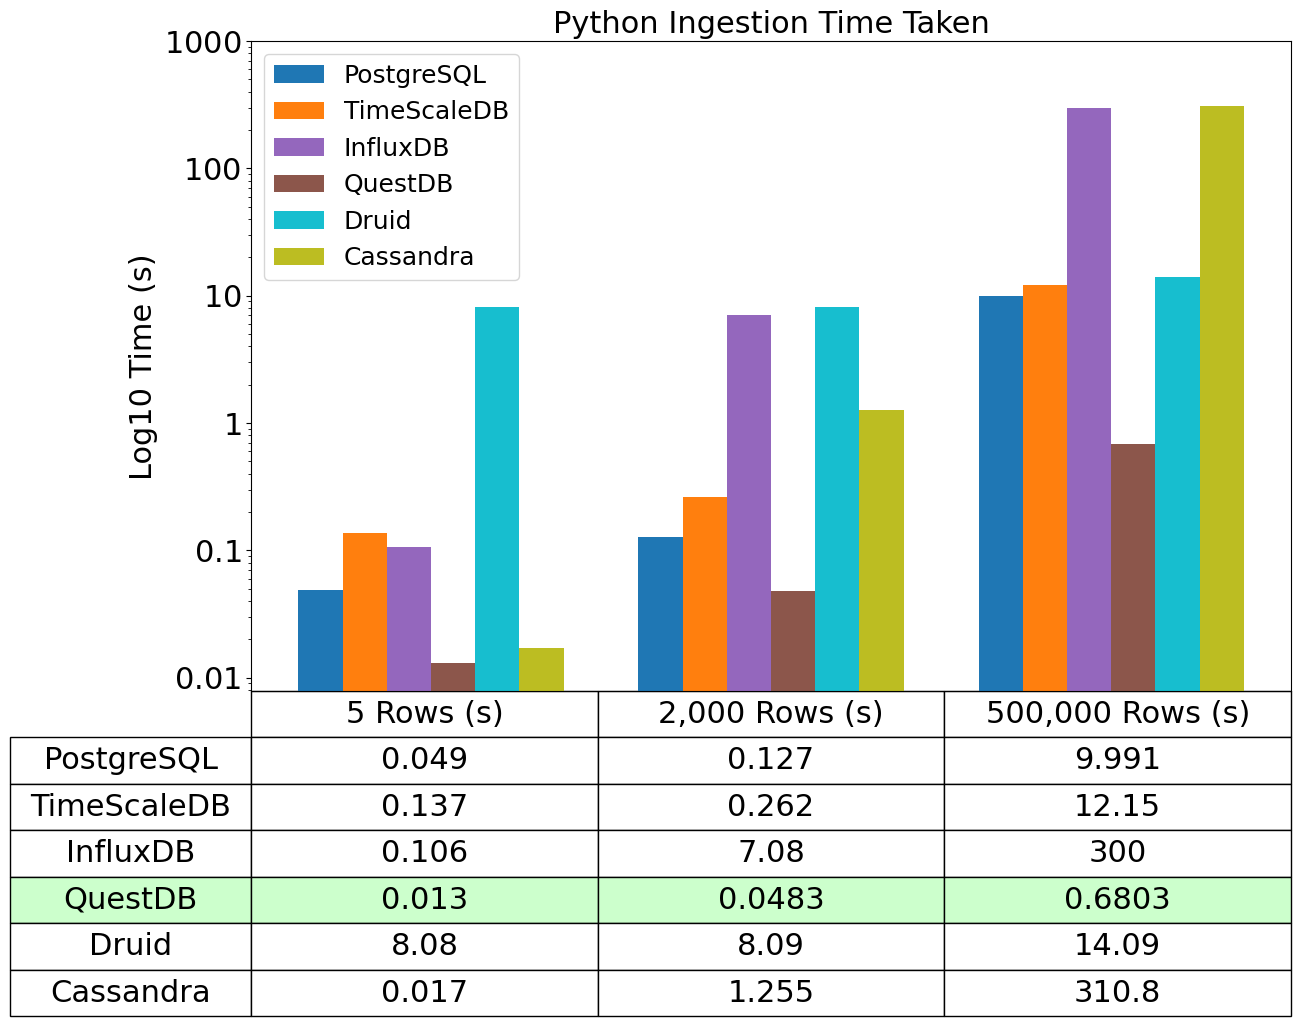

In [ ]:
#new code for python ingestion
import matplotlib.pyplot as plt
import numpy as np

# Set font size
plt.rcParams.update({'font.size': 22})

# Data setup
databases = ['PostgreSQL', 'TimeScaleDB', 'InfluxDB', 'QuestDB', 'Druid', 'Cassandra']
row_sizes = ['5 Rows (s)', '2,000 Rows (s)', '500,000 Rows (s)']  # ← units added
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b', '#17becf', '#bcbd22']

# Data
data = np.array([
    [0.049, 0.127, 9.991],
    [0.137, 0.262, 12.155],
    [0.106, 7.08, 300],
    [0.013, 0.0483, 0.6803],   # QuestDB
    [8.08, 8.09, 14.09],
    [0.017, 1.255, 310.751],
])

data_T = data.T
x = np.arange(len(row_sizes))
bar_width = 0.13

fig, ax = plt.subplots(figsize=(13, 13))

# Bar plot
for i in range(len(databases)):
    ax.bar(x + i * bar_width, data_T[:, i], width=bar_width, label=databases[i], color=colors[i])

# Y-axis
ax.set_yscale("log")
ax.set_ylabel("Log10 Time (s)")
ax.set_yticks([0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels(['$0.01$', '$0.1$', '$1$', '$10$', '$100$', '$1000$'])

# Remove x-axis ticks
ax.set_xticks([])
ax.set_xlabel("")
ax.grid(False)

# Title and legend
ax.set_title("Python Ingestion Time Taken", fontsize=22)
ax.legend(fontsize=18)

# Table
cell_text = [[f"{data[i][j]:.4g}" for j in range(len(row_sizes))] for i in range(len(databases))]
table = plt.table(
    cellText=cell_text,
    rowLabels=databases,
    colLabels=row_sizes,
    cellLoc='center',
    rowLoc='center',
    loc='bottom',
    bbox=[0.0, -0.5, 1.0, 0.5]
)

# Make column headers larger & bold
for col in range(len(row_sizes)):
    table.get_celld()[(0, col)].set_fontsize(22)
    table.get_celld()[(0, col)].set_text_props()

# ✅ Highlight QuestDB row including label
highlight_color = '#ccffcc'
questdb_row_index = 4  # 0-based index
for col in range(-1, len(row_sizes)):
    table.get_celld()[(questdb_row_index, col)].set_facecolor(highlight_color)

# Layout
plt.subplots_adjust(left=0.1, bottom=0.38)

# Save
plt.savefig("python_ingestiontime_final.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download("python_ingestiontime_final.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

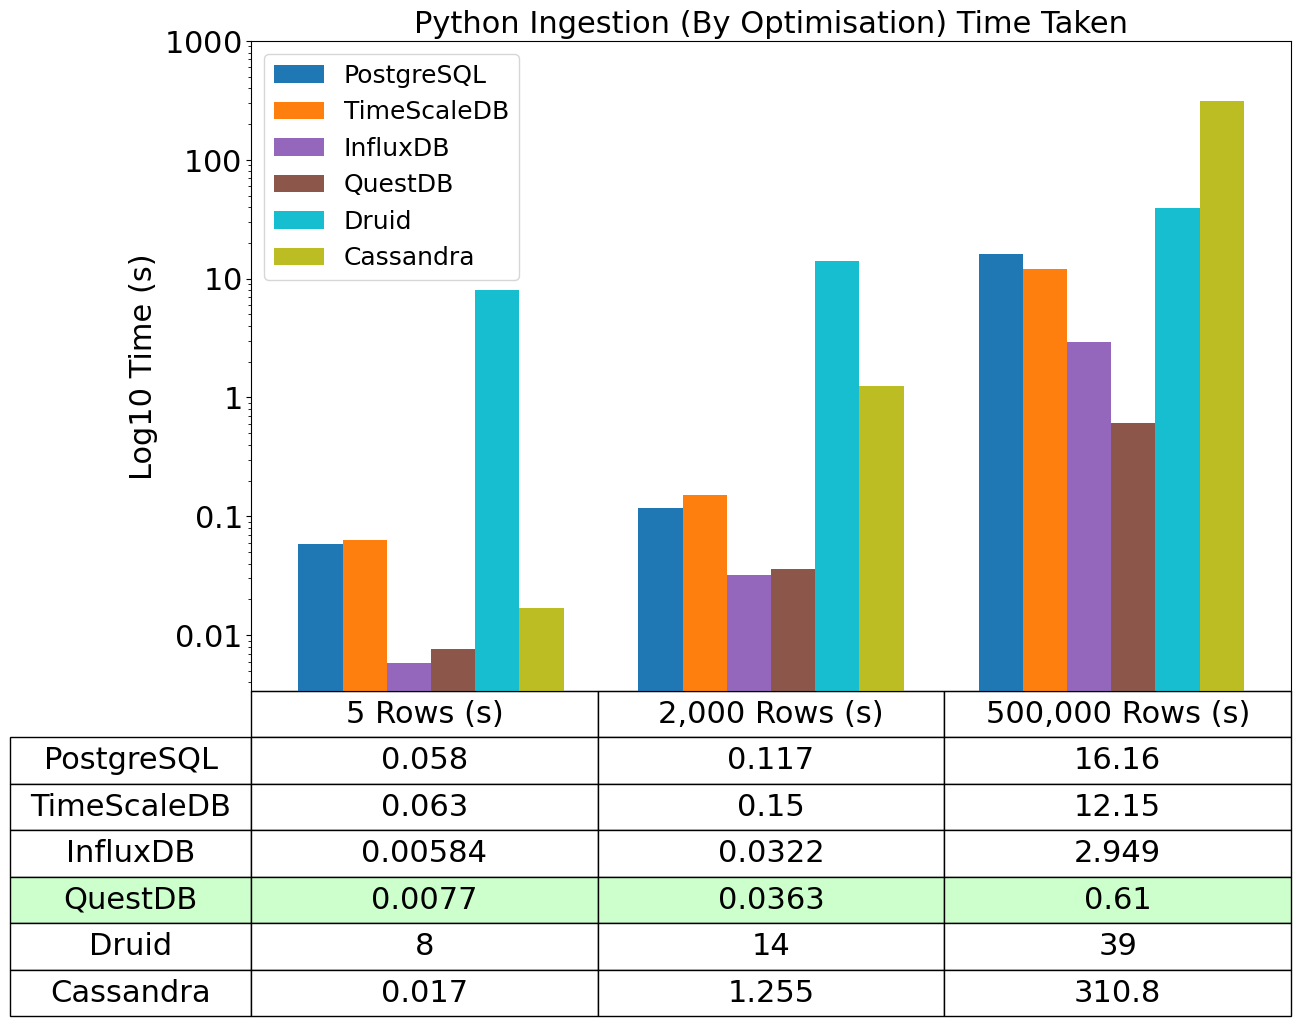

In [ ]:
#new code for optimsation with python ingestion


import matplotlib.pyplot as plt
import numpy as np

# Updated data
databases = ['PostgreSQL', 'TimeScaleDB', 'InfluxDB', 'QuestDB', 'Druid', 'Cassandra']
row_sizes = ['5 Rows (s)', '2,000 Rows (s)', '500,000 Rows (s)']  # ← added units
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b','#17becf', '#bcbd22']

# New injection time values
data = np.array([
    [0.058, 0.117, 16.157],     # PostgreSQL
    [0.063, 0.15, 12.155],      # TimeScaleDB
    [0.00584, 0.032199, 2.949], # InfluxDB
    [0.0077, 0.0363, 0.61],     # QuestDB
    [8, 14, 39],                # Druid
    [0.017, 1.255, 310.751]     # Cassandra
])

data_T = data.T
x = np.arange(len(row_sizes))
bar_width = 0.13

fig, ax = plt.subplots(figsize=(13, 13))

# Plot bars
for i in range(len(databases)):
    ax.bar(x + i * bar_width, data_T[:, i], width=bar_width, label=databases[i], color=colors[i])

# Y-axis settings
ax.set_yscale("log")
ax.set_ylabel("Log10 Time (s)")
ax.set_yticks([0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels(['$0.01$', '$0.1$', '$1$', '$10$', '$100$', '$1000$'])

# X-axis and title
ax.set_xticks([])
ax.set_xlabel("")
ax.set_title("Python Ingestion (By Optimisation) Time Taken", fontsize=22)
ax.legend(fontsize=18)

# Table below plot
cell_text = [[f"{data[i][j]:.4g}" for j in range(len(row_sizes))] for i in range(len(databases))]
table = plt.table(
    cellText=cell_text,
    rowLabels=databases,
    colLabels=row_sizes,
    cellLoc='center',
    rowLoc='center',
    loc='bottom',
    bbox=[0.0, -0.5, 1.0, 0.5]
)

# Make column headers larger & bold
for col in range(len(row_sizes)):
    table.get_celld()[(0, col)].set_fontsize(22)
    table.get_celld()[(0, col)].set_text_props()

# ✅ Highlight QuestDB row (index 3, include label col = -1)
highlight_color = '#ccffcc'
questdb_row_index = 4
for col in range(-1, len(row_sizes)):
    table.get_celld()[(questdb_row_index, col)].set_facecolor(highlight_color)

# Adjust layout
plt.subplots_adjust(left=0.1, bottom=0.38)

plt.savefig("python_ingestion_optimisation_plot_final.pdf", format='pdf', bbox_inches='tight')
plt.show()



In [ ]:
from google.colab import files
files.download("python_ingestion_optimisation_plot_final.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

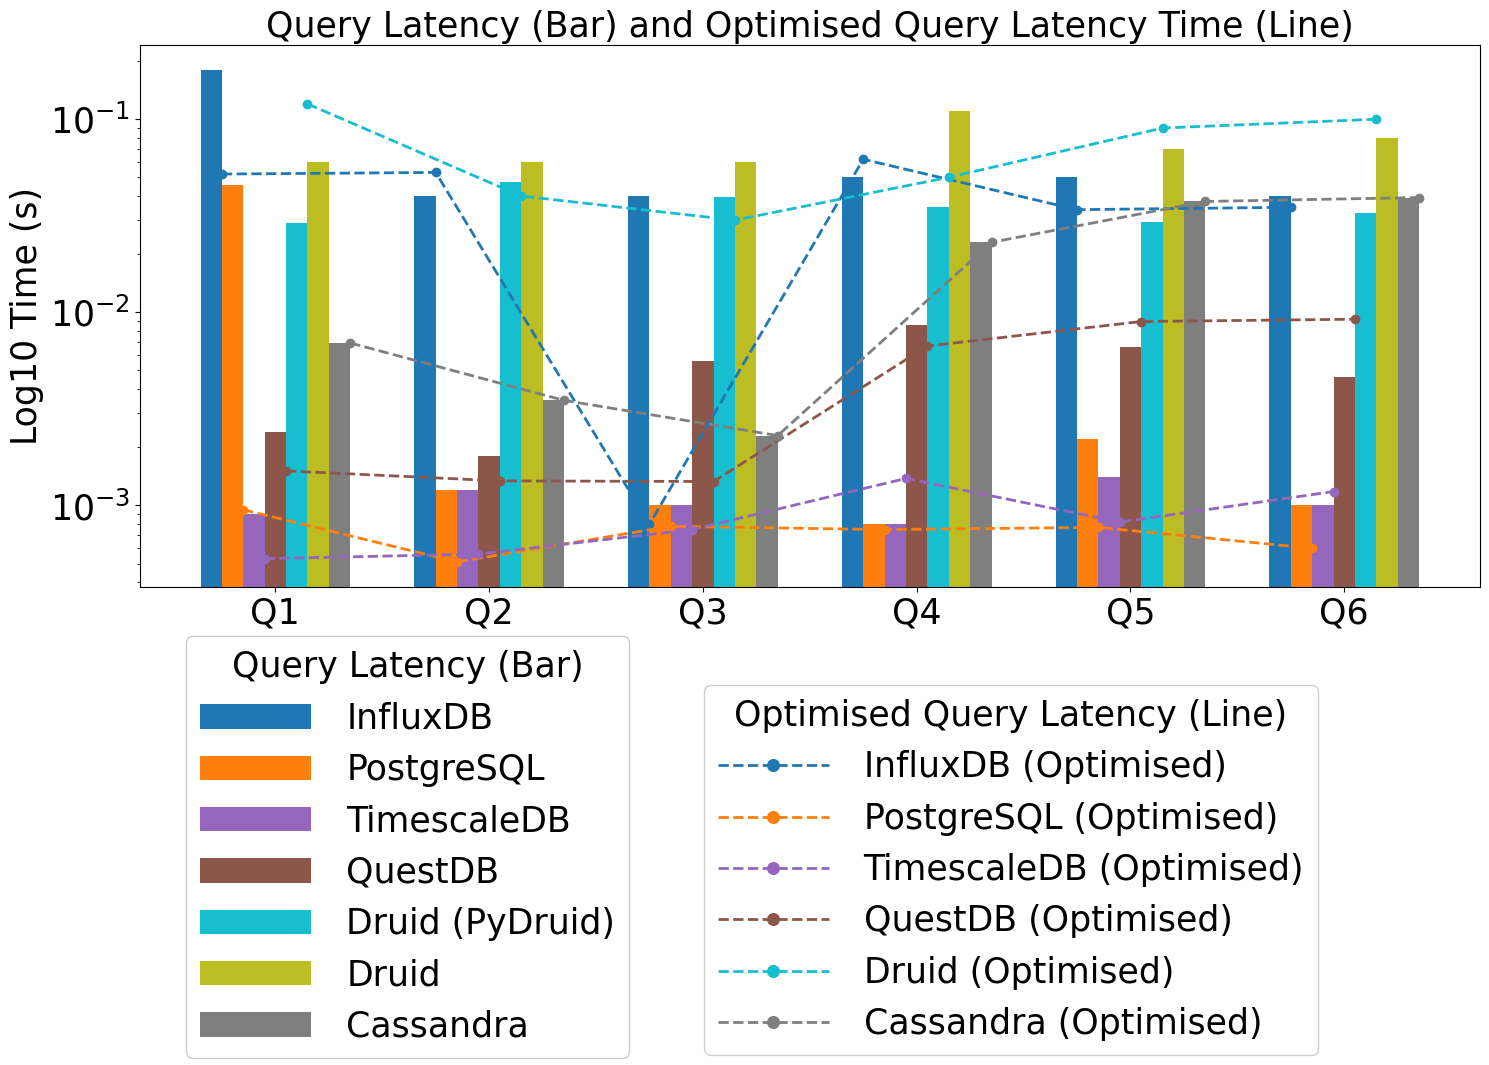

In [17]:
# new code for query latency for 5 rows #right one
import numpy as np
import matplotlib.pyplot as plt

BASE = 16  # single size used everywhere

# Labels
query_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']
databases = ['InfluxDB', 'PostgreSQL', 'TimescaleDB', 'QuestDB',
             'Druid (PyDruid)', 'Druid', 'Cassandra']

# Bar plot data (query latency via Python, 7 databases)
query_latency = np.array([
    [0.1800, 0.0457, 0.0009, 0.0024, 0.0291, 0.0600, 0.0069],
    [0.0400, 0.0012, 0.0012, 0.0018, 0.0472, 0.0600, 0.0035],
    [0.0400, 0.0010, 0.0010, 0.0056, 0.0394, 0.0600, 0.0023],
    [0.0500, 0.0008, 0.0008, 0.0086, 0.0349, 0.1100, 0.0231],
    [0.0500, 0.0022, 0.0014, 0.0066, 0.0293, 0.0700, 0.0375],
    [0.0400, 0.0010, 0.0010, 0.0046, 0.0326, 0.0800, 0.0393]
])

# Line plot data (optimised ingestion; skip NaN column for Druid UI)
injection_latency = np.array([
    [0.0520, 0.00095, 0.00053, 0.00151, 0.1200, np.nan, 0.00694],
    [0.0530, 0.00051, 0.00056, 0.00134, 0.0400, np.nan, 0.00350],
    [0.0008, 0.00078, 0.00075, 0.00133, 0.0300, np.nan, 0.00230],
    [0.0620, 0.00075, 0.00138, 0.00669, 0.0500, np.nan, 0.02305],
    [0.0340, 0.00077, 0.00082, 0.00896, 0.0900, np.nan, 0.03750],
    [0.0350, 0.00060, 0.00118, 0.00921, 0.1000, np.nan, 0.03930]
])

# Plotting setup
fig, ax = plt.subplots(figsize=(15, 13))
bar_width = 0.1
x = np.arange(len(query_labels))

colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b',
          '#17becf', '#bcbd22', '#7f7f7f']

# Collect handles for legends
bar_handles, line_handles = [], []

# Bars
for i, db in enumerate(databases):
    b = ax.bar(x + i * bar_width, query_latency[:, i], width=bar_width,
               label=db, color=colors[i])
    bar_handles.append(b[0])

# Lines
for i, db in enumerate(databases):
    if np.isnan(injection_latency[:, i]).all():
        continue
    label = "Druid (Optimised)" if db == "Druid (PyDruid)" else f"{db} (Optimised)"
    l, = ax.plot(x + i * bar_width + bar_width / 2,
                 injection_latency[:, i],
                 color=colors[i], linestyle='--', marker='o',
                 linewidth=2, markersize=6, label=label)
    line_handles.append(l)

# Axes formatting (uniform size)
ax.set_ylabel("Log10 Time (s)", fontsize=25)
ax.set_title("Query Latency (Bar) and Optimised Query Latency Time (Line)",
             fontsize=25)
ax.set_xticks(x + bar_width * 3)
ax.set_xticklabels(query_labels, fontsize=25)
ax.set_yscale("log")
ax.tick_params(axis='y', labelsize=25)

# Legends (uniform size)
legend1 = ax.legend(
    bar_handles, databases,
    loc='upper center', bbox_to_anchor=(0.20, -0.06),
    ncol=1, title="Query Latency (Bar)",
    fontsize=25, title_fontsize=25,
    handlelength=3.2, handletextpad=1.0,
    frameon=True, fancybox=True, framealpha=0.97
)

legend2 = ax.legend(
    line_handles, [h.get_label() for h in line_handles],
    loc='upper center', bbox_to_anchor=(0.65, -0.15),
    ncol=1, title="Optimised Query Latency (Line)",
    fontsize=25, title_fontsize=25,
    handlelength=3.2, handletextpad=1.0,
    markerscale=1.4,
    frameon=True, fancybox=True, framealpha=0.97
)

ax.add_artist(legend1)  # keep both legends

# Give bottom room for legends
plt.tight_layout(rect=[0, 0.12, 1, 1])

# Save
pdf_path = "query_latency_via_python5rowscombined_L.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
plt.show()


In [18]:
from google.colab import files
files.download("query_latency_via_python5rowscombined_L.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

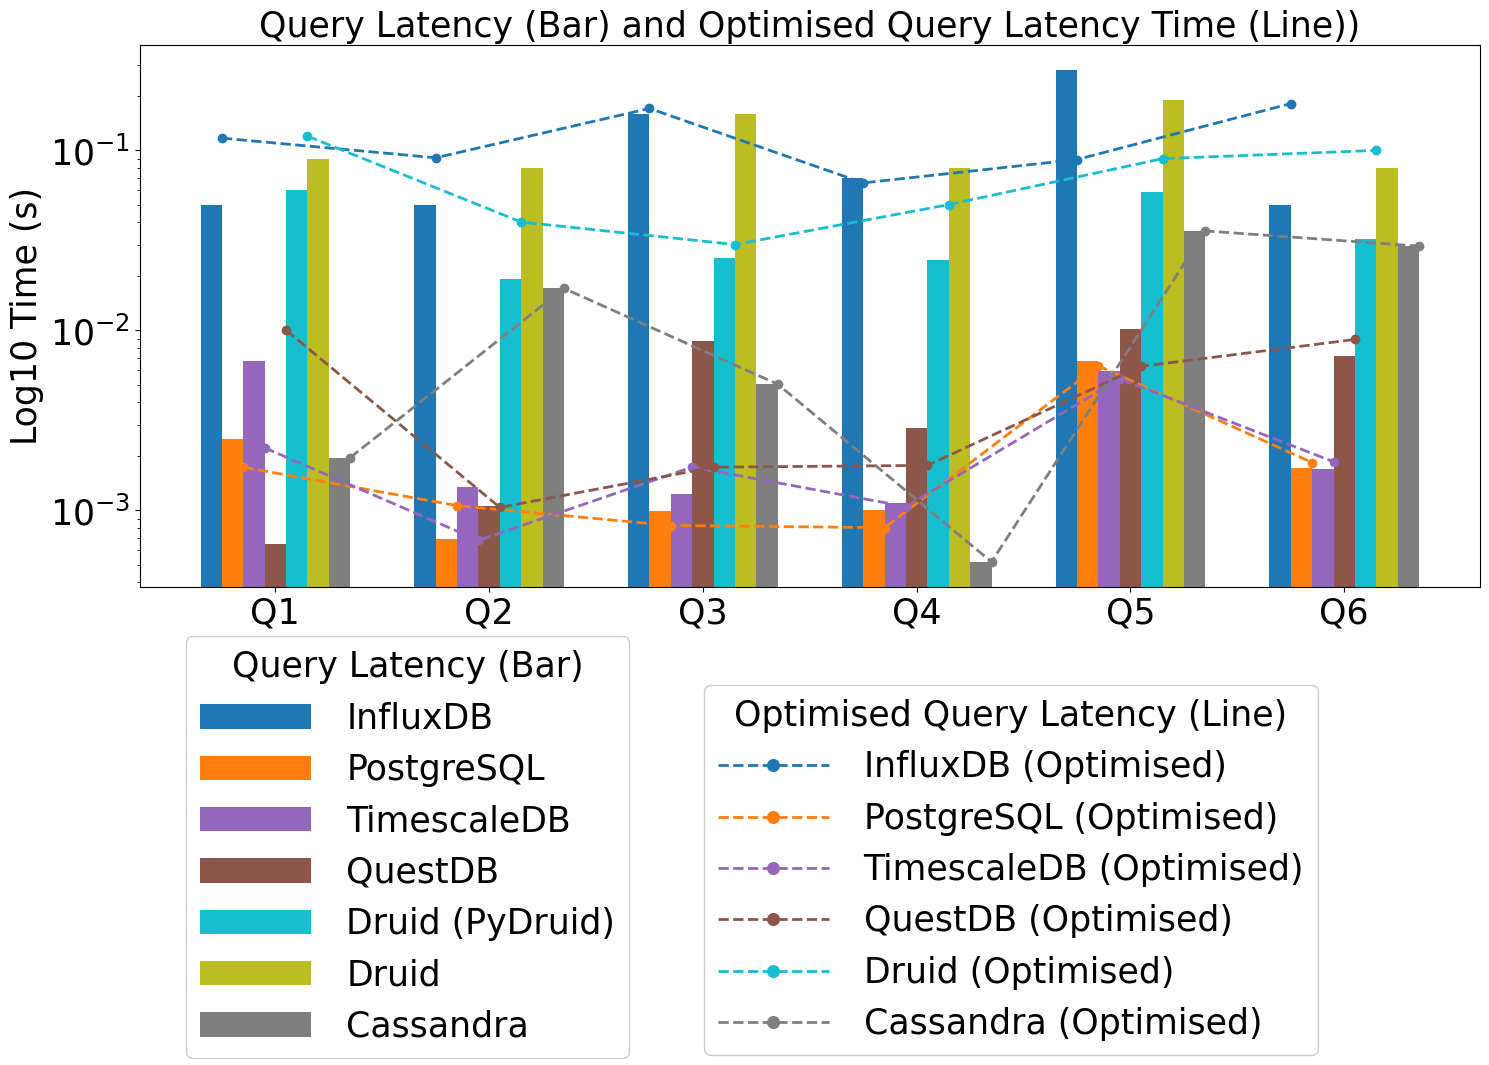

In [16]:
# 2k rows —new code
import numpy as np
import matplotlib.pyplot as plt

BASE = 16  # uniform font size

# Labels/order locked to match 5-rows
query_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']
databases = ['InfluxDB', 'PostgreSQL', 'TimescaleDB', 'QuestDB',
             'Druid (PyDruid)', 'Druid', 'Cassandra']

# Fixed colors across figures
color_map = {
    'InfluxDB': '#1f77b4',
    'PostgreSQL': '#ff7f0e',
    'TimescaleDB': '#9467bd',
    'QuestDB': '#8c564b',
    'Druid (PyDruid)': '#17becf',
    'Druid': '#bcbd22',
    'Cassandra': '#7f7f7f'
}
colors = [color_map[db] for db in databases]

# ----- Raw data you provided (seconds) -----
# Bars (original order here: PostgreSQL, TimescaleDB, InfluxDB, QuestDB, Druid py, Druid (UI), Cassandra)
bar_raw = np.array([
    [0.00251, 0.006788, 0.05,   0.000654, 0.06, 0.09,  0.001967],  # Q1
    [0.000691,0.001347, 0.05,   0.00106,0.0193,0.08, 0.01713 ],  # Q2
    [0.000999,0.001227, 0.16,   0.00872,0.0254,0.16, 0.005028],  # Q3
    [0.001002,0.001104, 0.07,   0.00288,0.0246,0.08, 0.000518],  # Q4
    [0.006734,0.005963, 0.28,   0.01022,0.0587,0.19, 0.0357  ],  # Q5
    [0.001714,0.001703, 0.05,   0.00721,0.0322,0.08, 0.0294  ]   # Q6
])

# Lines (optimised). Original order: PostgreSQL(Idx), TimescaleDB(Idx), InfluxDB(Grafana),
# QuestDB(Idx), Druid(Rolled-up), [Druid UI missing], Cassandra
line_raw = np.array([
    [0.001739,0.002229,0.117, 0.01004,0.12,   np.nan, 0.001967],  # Q1
    [0.001064,0.000682,0.091, 0.00104,0.04,   np.nan, 0.01713 ],  # Q2
    [0.000825,0.001743,0.171, 0.00174,0.03,   np.nan, 0.005028],  # Q3
    [0.000803,0.001051,0.066, 0.00178,0.05,   np.nan, 0.000518],  # Q4
    [0.006359,0.00539, 0.089, 0.00632,0.09,   np.nan, 0.0357  ],  # Q5
    [0.001844,0.001865,0.182, 0.00891,0.10,   np.nan, 0.0294  ]   # Q6
])

# Reorder columns to our canonical order: InfluxDB, PostgreSQL, TimescaleDB, QuestDB, Druid (PyDruid), Druid (UI), Cassandra
orig_cols = ['PostgreSQL','TimescaleDB','InfluxDB','QuestDB','Druid (PyDruid)','Druid','Cassandra']
target_cols = ['InfluxDB','PostgreSQL','TimescaleDB','QuestDB','Druid (PyDruid)','Druid','Cassandra']
idx = [orig_cols.index(c) for c in target_cols]

query_latency = bar_raw[:, idx]
injection_latency = line_raw[:, idx]

# ----- Plot -----
fig, ax = plt.subplots(figsize=(15, 13))
bar_width = 0.1
x = np.arange(len(query_labels))

# Handles for legends
bar_handles, line_handles = [], []

# Bars
for i, db in enumerate(databases):
    b = ax.bar(x + i * bar_width, query_latency[:, i], width=bar_width,
               label=db, color=colors[i])
    bar_handles.append(b[0])

# Lines
for i, db in enumerate(databases):
    if np.isnan(injection_latency[:, i]).all():
        continue
    lbl = "Druid (Optimised)" if db == "Druid (PyDruid)" else f"{db} (Optimised)"
    l, = ax.plot(x + i * bar_width + bar_width/2, injection_latency[:, i],
                 color=colors[i], linestyle='--', marker='o',
                 linewidth=2, markersize=6, label=lbl)
    line_handles.append(l)

# Axes formatting (your template)
ax.set_ylabel("Log10 Time (s)", fontsize=25)
ax.set_title("Query Latency (Bar) and Optimised Query Latency Time (Line))",
             fontsize=25)
ax.set_xticks(x + bar_width * 3)
ax.set_xticklabels(query_labels, fontsize=25)
ax.set_yscale("log")
ax.tick_params(axis='y', labelsize=25)

# Legends (same positions/sizes as 5-rows "right one")
legend1 = ax.legend(
    bar_handles, databases,
    loc='upper center', bbox_to_anchor=(0.20, -0.06),
    ncol=1, title="Query Latency (Bar)",
    fontsize=25, title_fontsize=25,
    handlelength=3.2, handletextpad=1.0,
    frameon=True, fancybox=True, framealpha=0.97
)
legend2 = ax.legend(
    line_handles, [h.get_label() for h in line_handles],
    loc='upper center', bbox_to_anchor=(0.65, -0.15),
    ncol=1, title="Optimised Query Latency (Line)",
    fontsize=25, title_fontsize=25,
    handlelength=3.2, handletextpad=1.0,
    markerscale=1.4,
    frameon=True, fancybox=True, framealpha=0.97
)
ax.add_artist(legend1)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("query_latency_via_python2krowscombined_L.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [19]:
from google.colab import files
files.download("query_latency_via_python2krowscombined_L.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

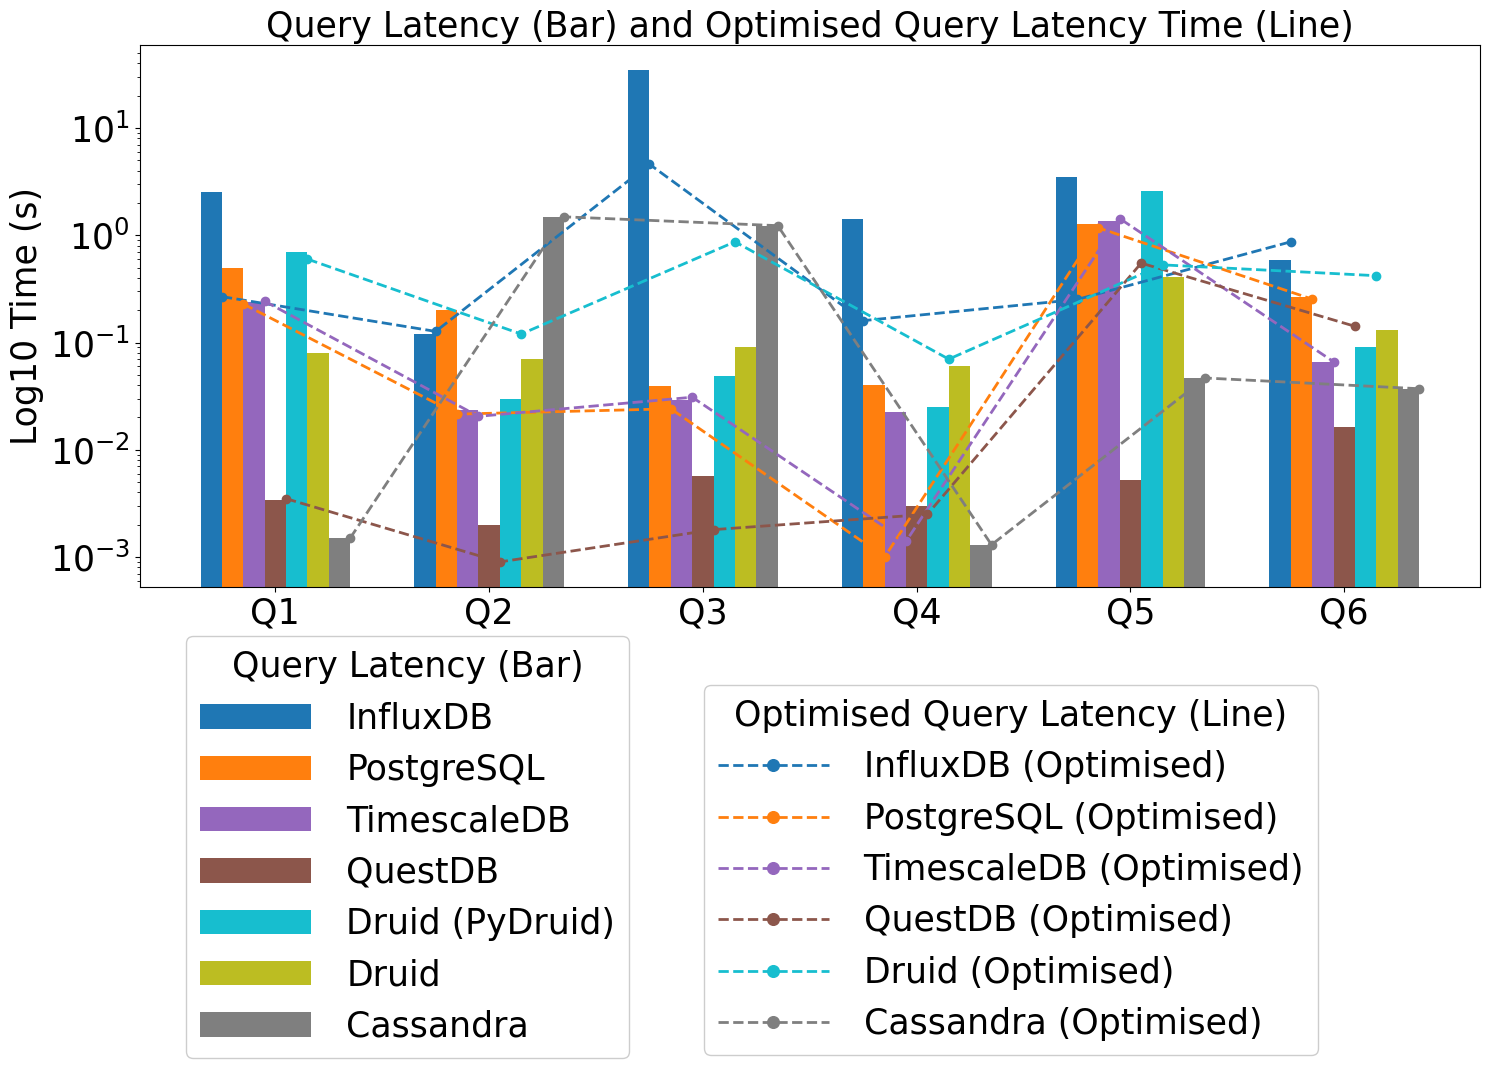

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Desired display/legend order ----
databases = ['InfluxDB', 'PostgreSQL', 'TimescaleDB', 'QuestDB',
             'Druid (PyDruid)', 'Druid', 'Cassandra']

# Consistent colors
color_map = {
    'InfluxDB': '#1f77b4',
    'PostgreSQL': '#ff7f0e',
    'TimescaleDB': '#9467bd',
    'QuestDB': '#8c564b',
    'Druid (PyDruid)': '#17becf',
    'Druid': '#bcbd22',
    'Cassandra': '#7f7f7f'
}
colors = [color_map[d] for d in databases]

# Labels
query_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']

# ---- INPUT VALUES (seconds) in original column order ----
orig_cols = ['PostgreSQL','TimescaleDB','InfluxDB','QuestDB','Druid (PyDruid)','Druid','Cassandra']

# Bars: Query latency via Python
bar_raw = np.array([
    [0.4929, 0.2368, 2.5600, 0.0034, 0.7000, 0.0800, 0.0015],  # Q1
    [0.1997, 0.0234, 0.1200, 0.0020, 0.0300, 0.0700, 1.4870],  # Q2
    [0.0390, 0.0290, 34.8600,0.0057, 0.0483, 0.0900, 1.2300],  # Q3
    [0.0406, 0.0225, 1.4100, 0.0030, 0.0248, 0.0600, 0.0013],  # Q4
    [1.2880, 1.3673, 3.5300, 0.0052, 2.5749, 0.4100, 0.0467],  # Q5
    [0.2666, 0.0665, 0.5900, 0.0163, 0.0902, 0.1300, 0.0371]   # Q6
])

# Lines: Optimised ingestion (no Druid UI → NaN)
line_raw = np.array([
    [0.2289,0.2428,0.2680,0.0035,0.6000, np.nan, 0.0015],  # Q1 (PostgreSQL,TimescaleDB,InfluxDB,...)
    [0.0215,0.0205,0.1270,0.0009,0.1200, np.nan, 1.4870],  # Q2
    [0.0241,0.0309,4.6000,0.0018,0.8700, np.nan, 1.2300],  # Q3
    [0.0010,0.0014,0.1600,0.0025,0.0700, np.nan, 0.0013],  # Q4
    [1.1722,1.4318,0.2520,0.5502,0.5300, np.nan, 0.0467],  # Q5
    [0.2539,0.0662,0.8700,0.1417,0.4200, np.nan, 0.0371]   # Q6
])

# ---- Reorder to the requested display order ----
target = ['InfluxDB','PostgreSQL','TimescaleDB','QuestDB','Druid (PyDruid)','Druid','Cassandra']
idx = [orig_cols.index(c) for c in target]

query_latency = bar_raw[:, idx]
injection_latency = line_raw[:, idx]

# ---- Plot (your "right one" style) ----
BASE = 16
fig, ax = plt.subplots(figsize=(15, 13))
bar_width = 0.1
x = np.arange(len(query_labels))

bar_handles, line_handles = [], []

# Bars
for i, db in enumerate(databases):
    b = ax.bar(x + i*bar_width, query_latency[:, i], width=bar_width,
               label=db, color=colors[i])
    bar_handles.append(b[0])

# Lines
for i, db in enumerate(databases):
    y = injection_latency[:, i]
    if np.isnan(y).all():
        continue
    lbl = "Druid (Optimised)" if db == "Druid (PyDruid)" else f"{db} (Optimised)"
    l, = ax.plot(x + i*bar_width + bar_width/2, y,
                 color=colors[i], linestyle='--', marker='o',
                 linewidth=2, markersize=6, label=lbl)
    line_handles.append(l)

# Axes
ax.set_ylabel("Log10 Time (s)", fontsize=25)
ax.set_title("Query Latency (Bar) and Optimised Query Latency Time (Line)",
             fontsize=25)
ax.set_xticks(x + bar_width*3)
ax.set_xticklabels(query_labels, fontsize=25)
ax.set_yscale("log")
ax.tick_params(axis='y', labelsize=25)

# Legends
legend1 = ax.legend(
    bar_handles, databases,
    loc='upper center', bbox_to_anchor=(0.20, -0.06),
    ncol=1, title="Query Latency (Bar)",
    fontsize=25, title_fontsize=25,
    handlelength=3.2, handletextpad=1.0,
    frameon=True, fancybox=True, framealpha=0.97
)
legend2 = ax.legend(
    line_handles, [h.get_label() for h in line_handles],
    loc='upper center', bbox_to_anchor=(0.65, -0.15),
    ncol=1, title="Optimised Query Latency (Line)",
    fontsize=25, title_fontsize=25,
    handlelength=3.2, handletextpad=1.0,
    markerscale=1.4,
    frameon=True, fancybox=True, framealpha=0.97
)
ax.add_artist(legend1)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("query_latency_via_python500krowscombined_L.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [20]:
from google.colab import files
files.download("query_latency_via_python500krowscombined_L.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>